## Binary Classification

In [36]:
import torch
import warnings
warnings.filterwarnings('ignore')

### STEP 1. Make Data

In [30]:
# case 1
N=20
random0=torch.randn(int(N/2),1)
random5=torch.randn(int(N/2),1)+5
class1_data=torch.hstack([random0,random5])
class2_data=torch.hstack([random5,random0])
class1_label=torch.ones(int(N/2),1)
class2_label=torch.zeros(int(N/2),1)
X=torch.vstack([class1_data,class2_data])
y=torch.vstack([class1_label,class2_label])

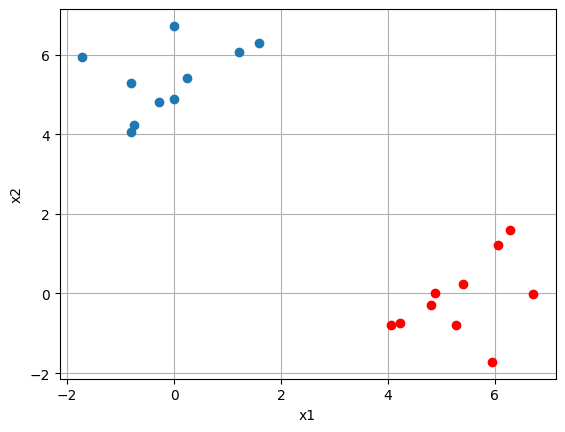

In [3]:
import matplotlib.pyplot as plt
plt.plot(class1_data[:,0],class1_data[:,1],'o')
plt.plot(class2_data[:,0],class2_data[:,1],'ro')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

### STEP 2. Make Model

In [41]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
    # case 1, plain
        self.linear = nn.Sequential(nn.Linear(2, 10),
                                    nn.Sigmoid(),
                                    nn.Linear(10, 1), # 확률 값 하나만..?
                                    nn.Sigmoid()) # 확률 하나만 시그모이드 통과해도 이진분류 가능하잖슴
        
    def forward(self, x):
        x = self.linear(x)
        return x

In [42]:
model = MLP()
print(model)
print(model(torch.randn(5,2)))
print(model(torch.randn(5,2)).shape)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=10, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
tensor([[0.4713],
        [0.5005],
        [0.4657],
        [0.4628],
        [0.4585]], grad_fn=<SigmoidBackward0>)
torch.Size([5, 1])


In [ ]:
# x = torch.tensor([[1., 1], [9, 8], [0, 2]])
# model(x)

tensor([[0.5562],
        [0.4876],
        [0.5640]], grad_fn=<SigmoidBackward0>)

### STEP 3. 모델 학습시키기

In [43]:
from torch import optim
import torch.nn.functional as F

LR = 1e-1
EPOCH = 100

optimizer = optim.SGD(model.parameters(), lr=LR)
#optimizer = optim.Adam(model.parameters(), lr = LR)

loss_history = []

model.train() # train mode로 전환

for ep in range(EPOCH):
    # inference
    y_hat = model(X)
    
    # loss
    loss = F.binary_cross_entropy(y_hat, y) # 순서 중요!!!!!! 
    
    # update
    optimizer.zero_grad() # gradient을 0으로 초기화
                          # PyTorch는 backward() 할 때마다 gradient를 누적 -> epoch마다 grad 누적을 방지
    loss.backward() # back-prop
    optimizer.step() # parameter update
    
    # print loss
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {round(loss.item(),3)}" )
    print("-"*20)
    



Epoch: 1, train loss: 0.643
--------------------
Epoch: 2, train loss: 0.634
--------------------
Epoch: 3, train loss: 0.625
--------------------
Epoch: 4, train loss: 0.616
--------------------
Epoch: 5, train loss: 0.607
--------------------
Epoch: 6, train loss: 0.598
--------------------
Epoch: 7, train loss: 0.589
--------------------
Epoch: 8, train loss: 0.58
--------------------
Epoch: 9, train loss: 0.571
--------------------
Epoch: 10, train loss: 0.562
--------------------
Epoch: 11, train loss: 0.554
--------------------
Epoch: 12, train loss: 0.545
--------------------
Epoch: 13, train loss: 0.536
--------------------
Epoch: 14, train loss: 0.527
--------------------
Epoch: 15, train loss: 0.519
--------------------
Epoch: 16, train loss: 0.51
--------------------
Epoch: 17, train loss: 0.502
--------------------
Epoch: 18, train loss: 0.493
--------------------
Epoch: 19, train loss: 0.485
--------------------
Epoch: 20, train loss: 0.476
--------------------
Epoch: 21, 

In [ ]:
print(F.binary_cross_entropy(y_hat,y)) # 사실은 각 데이터의 cross_entropy를 구하고 평균을 한것
print(-torch.sum(torch.log(y_hat**y*(1-y_hat)**(1-y)))/N) # 구래서  N이 붙는다.

tensor(0.0438, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.0438, grad_fn=<DivBackward0>)


```python
x= torch.tensor([1.],requires_grad=True)
for _ in range(2):
    loss=x**2
    loss.backward()
    print(x.grad)
    x.grad = None
```
다음의 코드를 통해 pytorch에선 gradient가 각 epoch(반복)마다 누적이되는걸 확인할수 있다.
따라서 꼭

```python
optimizer.zero_grad()
```
를 쓰자!! 언제?? `backward()` 전에 !!

Text(0, 0.5, 'loss')

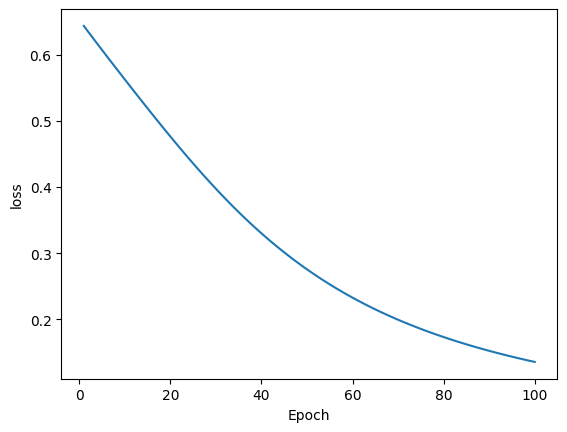

In [44]:
plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel('Epoch')
plt.ylabel('loss')

### STEP 4. 모델 테스트하기

In [45]:
x1_test=torch.linspace(-10,10,30) # case 1
x2_test=torch.linspace(-10,10,30) # case 1
X1_test, X2_test=torch.meshgrid(x1_test,x2_test)
X_test=torch.cat([X1_test.unsqueeze(dim=2), X2_test.unsqueeze(dim=2)], dim=2)


model.eval() # test mode로 # 1. 해결
with torch.no_grad(): # 2. 해결
    y_hat = model(X_test)
# 1. dropout 혹은 BN 같은거 사용했다면 train mode와 test mode 동작이 다르므로 eval()로 mode를 바꿔줘야
# 2. grad_fn 계산 <- 메모리가 불필요하게 쓰인다 
Y_hat = y_hat.squeeze()

Text(0.5, 0.5, 'x2')

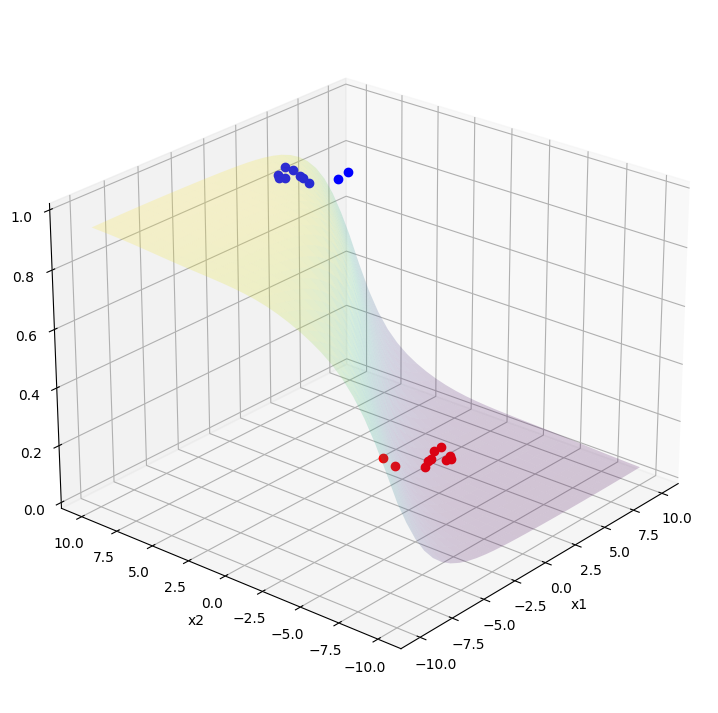

In [46]:
plt.figure(figsize=[10, 9]) # figsize=[가로, 세로]
ax = plt.axes(projection="3d")
ax.view_init(elev=25,azim=-140)
ax.plot_surface(X1_test,X2_test, Y_hat.numpy(), cmap="viridis", alpha=0.2)
plt.plot(class1_data[:,0],class1_data[:,1],class1_label.squeeze(),'bo')
plt.plot(class2_data[:,0],class2_data[:,1],class2_label.squeeze(),'ro')
plt.xlabel("x1")
plt.ylabel("x2")

In [40]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(x=X1_test, y=X2_test, z=Y_hat, colorscale="viridis", opacity=0.5)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
fig.update_layout(title='binary classification', width=700, height=600)

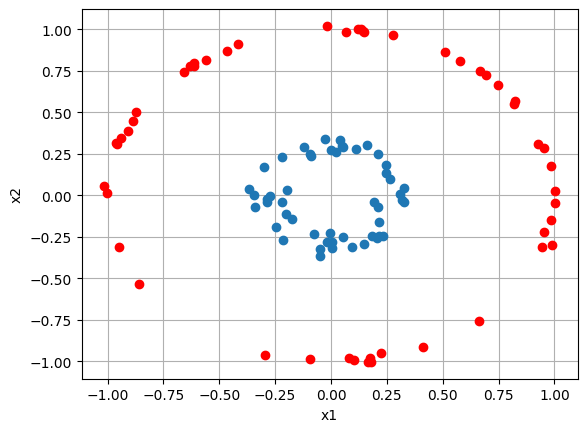

In [47]:
# case 2
N=100
radius1=0.3+0.05*torch.randn(int(N/2),1)
radius2=1+0.01*torch.randn(int(N/2),1)
theta1=2*torch.pi*torch.rand(int(N/2),1)-torch.pi
theta2=2*torch.pi*torch.rand(int(N/2),1)-torch.pi
class1_data=torch.hstack([radius1*torch.cos(theta1), radius1*torch.sin(theta1)])
class2_data=torch.hstack([radius2*torch.cos(theta2), radius2*torch.sin(theta2)])
class1_label=torch.ones(int(N/2),1)
class2_label=torch.zeros(int(N/2),1)
X=torch.vstack([class1_data,class2_data])
y=torch.vstack([class1_label,class2_label])

plt.plot(class1_data[:,0],class1_data[:,1],'o')
plt.plot(class2_data[:,0],class2_data[:,1],'ro')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

Epoch: 1, train loss: 0.695
--------------------
Epoch: 2, train loss: 0.82
--------------------
Epoch: 3, train loss: 0.704
--------------------
Epoch: 4, train loss: 0.708
--------------------
Epoch: 5, train loss: 0.739
--------------------
Epoch: 6, train loss: 0.733
--------------------
Epoch: 7, train loss: 0.712
--------------------
Epoch: 8, train loss: 0.697
--------------------
Epoch: 9, train loss: 0.693
--------------------
Epoch: 10, train loss: 0.698
--------------------
Epoch: 11, train loss: 0.705
--------------------
Epoch: 12, train loss: 0.708
--------------------
Epoch: 13, train loss: 0.706
--------------------
Epoch: 14, train loss: 0.701
--------------------
Epoch: 15, train loss: 0.696
--------------------
Epoch: 16, train loss: 0.693
--------------------
Epoch: 17, train loss: 0.694
--------------------
Epoch: 18, train loss: 0.696
--------------------
Epoch: 19, train loss: 0.699
--------------------
Epoch: 20, train loss: 0.7
--------------------
Epoch: 21, t

Text(0, 0.5, 'loss')

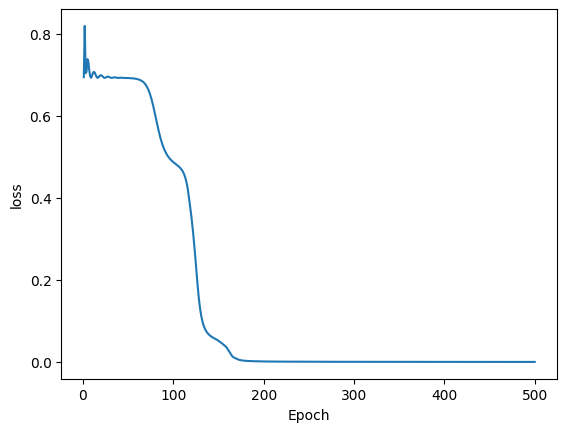

In [48]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear = nn.Sequential(nn.Linear(2, 100),
                                     nn.Sigmoid(),
                                     nn.Linear(100, 100),
                                     nn.Sigmoid(),
                                     nn.Linear(100, 100),
                                     nn.Sigmoid(),
                                     nn.Linear(100, 1),
                                     nn.Sigmoid())
        
        # # relu very deep
        # self.linear = nn.Sequential(nn.Linear(2, 100),
        #                             nn.Sigmoid(),
        #                             nn.Sequential(*[i for _ in range(10) for i in [nn.Linear(100,100), nn.Sigmoid()]]),
        #                             nn.Linear(100, 1),
        #                             nn.Sigmoid())
    
    def forward(self, x):
        x = self.linear(x)
        return x
    
model = MLP()

LR = 1e-2
EPOCH = 500

optimizer = optim.Adam(model.parameters(), lr = LR)
loss_history = []

model.train()
for ep in range(EPOCH):
    y_hat = model(X)
    loss = F.binary_cross_entropy(y_hat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history += [loss.item()]
    print(f"Epoch: {ep+1}, train loss: {round(loss.item(),3)}")
    print("-"*20)
    
plt.plot(range(1,EPOCH+1),loss_history)
plt.xlabel('Epoch')
plt.ylabel('loss')

In [49]:
x1_test=torch.linspace(-2,2,30) # case 2
x2_test=torch.linspace(-2,2,30) # case 2
X1_test, X2_test=torch.meshgrid(x1_test,x2_test)
X_test=torch.cat([X1_test.unsqueeze(dim=2), X2_test.unsqueeze(dim=2)], dim=2)

Text(0.5, 0.5, 'x2')

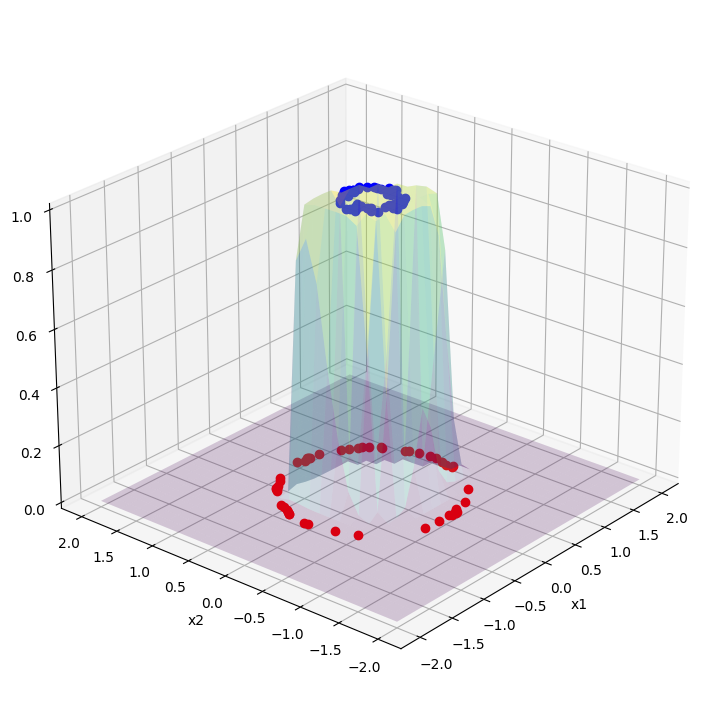

In [50]:
model.eval()

with torch.no_grad():
    y_hat = model(X_test)

Y_hat = y_hat.squeeze()
plt.figure(figsize=[10, 9]) # figsize=[가로, 세로]
ax = plt.axes(projection="3d")
ax.view_init(elev=25,azim=-140)
ax.plot_surface(X1_test,X2_test, Y_hat.numpy(), cmap="viridis", alpha=0.2)
plt.plot(class1_data[:,0],class1_data[:,1],class1_label.squeeze(),'bo')
plt.plot(class2_data[:,0],class2_data[:,1],class2_label.squeeze(),'ro')
plt.xlabel("x1")
plt.ylabel("x2")

In [51]:
fig = go.Figure(data=[go.Surface(x=X1_test, y=X2_test, z=Y_hat, colorscale="viridis", opacity=0.5)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
fig.update_layout(title='binary classification', width=700, height=600)